In [1]:
import math
import numpy as np

def planificar_limpieza_paneles(p_stc, hsp, eta_sys, tasa_suciedad_diaria, costo_limpieza, tarifa_kwh):
    """
    Calcula las pérdidas energéticas y determina el día óptimo para limpiar los paneles solares.

    Parámetros:
    p_stc (float): Potencia pico instalada del sistema en kW.
    hsp (float): Horas de Sol Pico promedio de la zona (horas/día).
    eta_sys (float): Rendimiento global del sistema (de 0.0 a 1.0).
    tasa_suciedad_diaria (float): Porcentaje de pérdida diaria por suciedad (ej. 0.005 para 0.5%).
    costo_limpieza (float): Costo físico/operativo de realizar una limpieza (en tu moneda/USD).
    tarifa_kwh (float): Precio de la tarifa eléctrica por kWh (en tu moneda/USD).
    """

    # 1. Calcular la energía teórica diaria (condición limpia)
    e_ideal_diaria = p_stc * hsp * eta_sys

    # 2. Determinar el tiempo óptimo (Día de equilibrio financiero)
    # Fórmula: T = sqrt((2 * Costo_limpieza) / (E_ideal * d * Tarifa))
    denominador = e_ideal_diaria * tasa_suciedad_diaria * tarifa_kwh

    if denominador == 0:
        return "Error: Los parámetros económicos o de generación no pueden ser cero."

    t_optimo = math.sqrt((2 * costo_limpieza) / denominador)
    t_optimo_redondeado = round(t_optimo)

    # 3. Proyección de pérdidas acumuladas en el punto óptimo
    energia_perdida_acumulada = e_ideal_diaria * tasa_suciedad_diaria * (t_optimo**2 / 2)
    costo_perdida_acumulado = energia_perdida_acumulada * tarifa_kwh

    # 4. Mostrar resultados detallados por consola
    print("=" * 60)
    print("   RESULTADOS DEL MODELO DE PREDICCIÓN Y PLANIFICACIÓN")
    print("=" * 60)
    print(f"Generación ideal estimada:     {e_ideal_diaria:.2f} kWh/día (Totalmente limpio)")
    print(f"Tasa de degradación diaria:    {tasa_suciedad_diaria * 100:.2f}% de pérdida por día")
    print(f"Pérdida económica diaria inicial: ${e_ideal_diaria * tasa_suciedad_diaria * tarifa_kwh:.2f} /día")
    print("-" * 60)
    print(f"TIEMPO ÓPTIMO DE LIMPIEZA:     ¡Cada {t_optimo_redondeado} días!")
    print("-" * 60)
    print(f"En el día {t_optimo_redondeado}, habrás acumulado:")
    print(f"  - Energía perdida:           {energia_perdida_acumulada:.2f} kWh")
    print(f"  - Costo de energía perdida:  ${costo_perdida_acumulado:.2f}")
    print(f"  - Costo del mantenimiento:   ${costo_limpieza:.2f}")
    print(f"Nota: Limpiar antes del día {t_optimo_redondeado} es más caro que la pérdida.")
    print(f"      Limpiar después del día {t_optimo_redondeado} incrementa tus pérdidas netas.")
    print("=" * 60)

    return t_optimo_redondeado

# =============================================================================
# EJECUCIÓN CON LOS DATOS DE EJEMPLO
# =============================================================================
# Configura aquí las variables reales de tu instalación:
PARAMETROS_PLANTA = {
    "p_stc": 100.0,              # Planta de 100 kWp
    "hsp": 5.0,                  # 5 Horas de Sol Pico promedio
    "eta_sys": 0.80,             # 80% de eficiencia general de la instalación
    "tasa_suciedad_diaria": 0.005,# 0.5% de pérdida diaria por polvo/suciedad
    "costo_limpieza": 150.0,     # Cuesta $150 limpiar toda la planta
    "tarifa_kwh": 0.15           # El costo de la red eléctrica es de $0.15 por kWh
}

# Llamada a la función
dia_mantenimiento = planificar_limpieza_paneles(**PARAMETROS_PLANTA)


   RESULTADOS DEL MODELO DE PREDICCIÓN Y PLANIFICACIÓN
Generación ideal estimada:     400.00 kWh/día (Totalmente limpio)
Tasa de degradación diaria:    0.50% de pérdida por día
Pérdida económica diaria inicial: $0.30 /día
------------------------------------------------------------
TIEMPO ÓPTIMO DE LIMPIEZA:     ¡Cada 32 días!
------------------------------------------------------------
En el día 32, habrás acumulado:
  - Energía perdida:           1000.00 kWh
  - Costo de energía perdida:  $150.00
  - Costo del mantenimiento:   $150.00
Nota: Limpiar antes del día 32 es más caro que la pérdida.
      Limpiar después del día 32 incrementa tus pérdidas netas.


   RESULTADOS DEL MODELO CON INTEGRACIÓN METEOROLÓGICA
Día óptimo teórico (Sin lluvia): Cada 27 días.

[RECOMENDACIÓN]: Clima seco garantizado.
-> Programe la limpieza física exactamente el día 27.


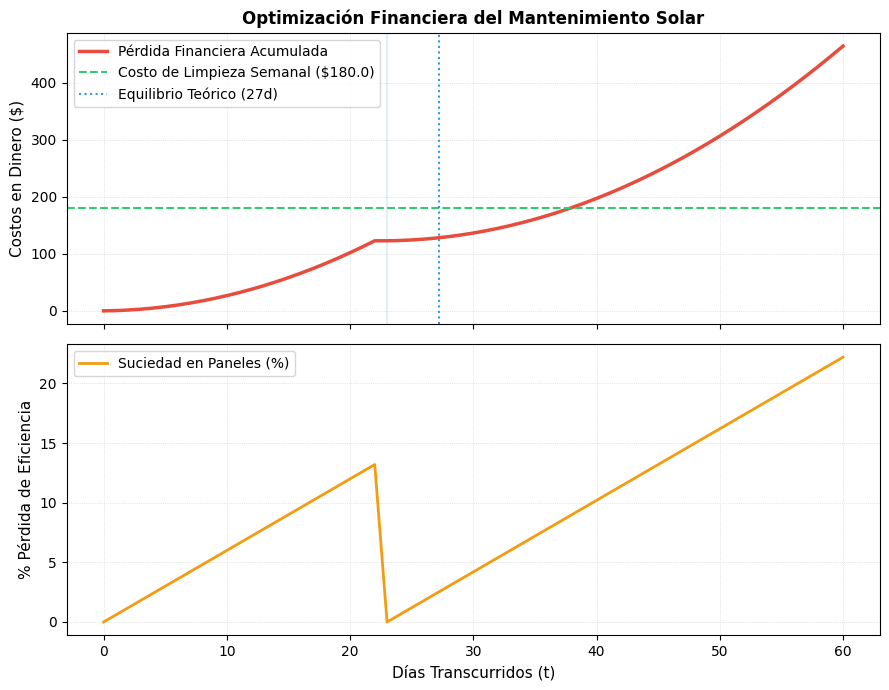

In [2]:
import math
import numpy as np
import matplotlib.pyplot as plt

def planificar_limpieza_avanzada(p_stc, hsp, eta_sys, tasa_suciedad_diaria, costo_limpieza, tarifa_kwh, pronostico_lluvia):
    """
    Calcula el día óptimo de limpieza, simula el impacto de las lluvias del pronóstico
    y genera una gráfica de equilibrio financiero.

    pronostico_lluvia: Lista de booleanos [True, False, ...] para los próximos 60 días.
                       True significa que llueve un día completo (limpieza natural).
    """
    # 1. Calcular la energía teórica diaria (limpio)
    e_ideal_diaria = p_stc * hsp * eta_sys

    # 2. Calcular el día óptimo teórico (fórmula matemática de equilibrio)
    denominador = e_ideal_diaria * tasa_suciedad_diaria * tarifa_kwh
    if denominador == 0:
        print("Error: Los parámetros no pueden ser cero.")
        return
    t_optimo_teorico = math.sqrt((2 * costo_limpieza) / denominador)

    # 3. Simulación día a día (60 días) incluyendo el efecto de la lluvia
    dias_simulacion = 60
    dias = np.arange(0, dias_simulacion + 1)

    suciedad_acumulada = []
    perdida_economica_acumulada = []

    suciedad_actual = 0.0
    perdida_dinero_total = 0.0

    for t in dias:
        if t == 0:
            suciedad_acumulada.append(0.0)
            perdida_economica_acumulada.append(0.0)
            continue

        # Si llueve el día anterior o hoy, la suciedad se resetea a 0 (lluvia fuerte)
        # Se asume un índice basado en la lista de pronóstico provista
        idx_lluvia = (t - 1) % len(pronostico_lluvia)
        if pronostico_lluvia[idx_lluvia]:
            suciedad_actual = 0.0
        else:
            suciedad_actual += tasa_suciedad_diaria

        # Pérdida de energía en el día t
        energia_perdida_hoy = e_ideal_diaria * suciedad_actual
        dinero_perdido_hoy = energia_perdida_hoy * tarifa_kwh

        perdida_dinero_total += dinero_perdido_hoy

        suciedad_acumulada.append(suciedad_actual * 100) # Guardar en %
        perdida_economica_acumulada.append(perdida_dinero_total)

    perdida_economica_acumulada = np.array(perdida_economica_acumulada)

    # 4. Evaluación de la decisión basada en el pronóstico
    t_optimo_redondeado = round(t_optimo_teorico)
    print("=" * 60)
    print("   RESULTADOS DEL MODELO CON INTEGRACIÓN METEOROLÓGICA")
    print("=" * 60)
    print(f"Día óptimo teórico (Sin lluvia): Cada {t_optimo_redondeado} días.")

    # Revisar si va a llover cerca del día óptimo (ventana de 3 días antes o después)
    lluvia_cercana = False
    dia_lluvia_detectada = -1
    for d in range(max(1, t_optimo_redondeado - 3), min(dias_simulacion, t_optimo_redondeado + 4)):
        if pronostico_lluvia[(d - 1) % len(pronostico_lluvia)]:
            lluvia_cercana = True
            dia_lluvia_detectada = d
            break

    if lluvia_cercana:
        print("\n[ALERTA METEOROLÓGICA]: Se detectó lluvia en el radar.")
        print(f"-> Se pronostica lluvia el día {dia_lluvia_detectada} (Cerca de tu fecha de limpieza).")
        print("-> RECOMENDACIÓN: ¡Pospón la limpieza manual! Deja que la lluvia limpie gratis.")
    else:
        print("\n[RECOMENDACIÓN]: Clima seco garantizado.")
        print(f"-> Programe la limpieza física exactamente el día {t_optimo_redondeado}.")
    print("=" * 60)

    # 5. Generación de Gráficas Profesionales
    fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(9, 7), sharex=True)

    # Gráfica 1: Pérdidas Financieras vs Costo de Limpieza
    ax1.plot(dias, perdida_economica_acumulada, label='Pérdida Financiera Acumulada', color='#e74c3c', linewidth=2.5)
    ax1.axhline(y=costo_limpieza, label=f'Costo de Limpieza Semanal (${costo_limpieza})', color='#2ecc71', linestyle='--')
    ax1.axvline(x=t_optimo_teorico, color='#3498db', linestyle=':', label=f'Equilibrio Teórico ({t_optimo_redondeado}d)')

    # Dibujar días de lluvia en la gráfica como líneas verticales azules de fondo
    for d in dias[1:]:
        if pronostico_lluvia[(d - 1) % len(pronostico_lluvia)]:
            ax1.axvline(x=d, color='#3498db', alpha=0.15, ymin=0, ymax=1)
            if d == dia_lluvia_detectada:
                ax1.axvline(x=d, color='#1abc9c', alpha=0.5, linestyle='-.', label='Lluvia que cancela limpieza')

    ax1.set_ylabel('Costos en Dinero ($)', fontsize=11)
    ax1.set_title('Optimización Financiera del Mantenimiento Solar', fontsize=12, fontweight='bold')
    ax1.grid(True, linestyle=':', alpha=0.6)
    ax1.legend(loc='upper left')

    # Gráfica 2: Comportamiento de la Suciedad (% de Eficiencia Perdida)
    ax2.plot(dias, suciedad_acumulada, label='Suciedad en Paneles (%)', color='#f39c12', linewidth=2)
    ax2.set_xlabel('Días Transcurridos (t)', fontsize=11)
    ax2.set_ylabel('% Pérdida de Eficiencia', fontsize=11)
    ax2.grid(True, linestyle=':', alpha=0.6)
    ax2.legend(loc='upper left')

    plt.tight_layout()
    plt.show()

# =============================================================================
# CONFIGURACIÓN DE PRUEBA
# =============================================================================
# Datos técnicos de la planta
DATOS_PLANTA = {
    "p_stc": 120.0,               # Planta de 120 kWp
    "hsp": 4.8,                   # 4.8 Horas de Sol Pico promedio
    "eta_sys": 0.78,              # Rendimiento real del sistema
    "tasa_suciedad_diaria": 0.006, # 0.6% de suciedad al día (Zona algo polvorienta)
    "costo_limpieza": 180.0,      # Costo del servicio técnico de limpieza
    "tarifa_kwh": 0.18            # Precio del kWh comercial
}

# Crear un pronóstico de ejemplo para 60 días:
# En este ejemplo ficticio, va a llover únicamente el día 23 de la simulación.
PRONOSTICO_60_DIAS = [False] * 60
PRONOSTICO_60_DIAS[22] = True  # El día 23 (índice 22) llueve copiosamente

# Ejecutar el software de cálculo y visualización
planificar_limpieza_avanzada(**DATOS_PLANTA, pronostico_lluvia=PRONOSTICO_60_DIAS)
